# Predict the Success of Bank Telemarketing

**Dataset Source:** Kaggle – Bank Marketing Dataset  

## Objective
To build a machine learning classification model that predicts whether a customer will subscribe to a bank term deposit based on demographic, financial, and campaign-related features.

## Problem Type
Binary Classification (Imbalanced Dataset)

## 1. Import Required Libraries

In [110]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import (StandardScaler, MinMaxScaler, OneHotEncoder)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import f1_score

import xgboost as xgb

## 2. Load Datasets
The training and test datasets are loaded from the Kaggle input directory.

In [6]:
# training dataset
path1 = '/kaggle/input/predict-the-success-of-bank-telemarketing/train.csv'
train_df = pd.read_csv(path1)

# test dataset
path2 = '/kaggle/input/predict-the-success-of-bank-telemarketing/test.csv'
test_df = pd.read_csv(path2)

# sample submission
path3  = '/kaggle/input/predict-the-success-of-bank-telemarketing/sample_submission.csv'
sample_submission = pd.read_csv(path3)


## 3. Initial Data Exploration
Examining dataset size, structure, and target distribution.

In [7]:
train_df.shape

(39211, 16)

In [8]:
train_df.head()

,last contact date,age,job,marital,education,default,balance,housing,loan,contact,duration,campaign,pdays,previous,poutcome,target
0,2009-04-17,26,blue-collar,married,secondary,no,647,yes,no,cellular,357,2,331,1,other,no
1,2009-10-11,52,technician,married,secondary,no,553,yes,no,telephone,160,1,-1,0,NaN,no
2,2010-11-20,44,blue-collar,married,secondary,no,1397,no,no,cellular,326,1,-1,0,NaN,no
3,2009-09-01,33,admin.,married,secondary,no,394,yes,no,telephone,104,3,-1,0,NaN,no
4,2008-01-29,31,entrepreneur,single,tertiary,no,137,no,no,cellular,445,2,-1,0,NaN,no


In [9]:

train_df['target'].value_counts()

target
no     33384
yes     5827
Name: count, dtype: int64

### Target Variable Distribution
-The target variable has two classes (`yes`, `no`).  
-This is **Binary classification problem** and Target data is **imbalance**.

In [111]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   last contact date  39211 non-null  datetime64[ns]
 1   age                39211 non-null  int64         
 2   job                38982 non-null  object        
 3   marital            39211 non-null  object        
 4   education          37744 non-null  object        
 5   default            39211 non-null  object        
 6   balance            39211 non-null  int64         
 7   housing            39211 non-null  object        
 8   loan               39211 non-null  object        
 9   contact            28875 non-null  object        
 10  duration           39211 non-null  int64         
 11  campaign           39211 non-null  int64         
 12  pdays              39211 non-null  int64         
 13  previous           39211 non-null  int64         
 14  poutco

## 4. Categorical Feature Analysis
Identifying categorical variables and their unique values.

In [11]:
cat_cols = train_df.select_dtypes(include = 'object').columns

In [12]:
for col in cat_cols:
    print(col,':', train_df[col].unique())

last contact date : ['2009-04-17' '2009-10-11' '2010-11-20' ... '2009-07-05' '2008-02-25'
 '2010-04-12']
job : ['blue-collar' 'technician' 'admin.' 'entrepreneur' 'unemployed'
 'management' 'services' 'student' 'self-employed' 'retired' 'housemaid'
 nan]
marital : ['married' 'single' 'divorced']
education : ['secondary' 'tertiary' 'primary' nan]
default : ['no' 'yes']
housing : ['yes' 'no']
loan : ['no' 'yes']
contact : ['cellular' 'telephone' nan]
poutcome : ['other' nan 'failure' 'success']
target : ['no' 'yes']


In [13]:
train_df[(train_df["target"]=='yes') & (train_df["duration"]>1000)].shape
# train_df[(train_df["target"]=='yes')].shape

(1794, 16)

## 5. Exploratory Data Analysis (EDA): Numerical Features
This section explores the distribution, spread, and potential outliers in numerical variables.


### Dataset Structure and Missing Values
Inspecting data types and identifying missing values across features.

In [14]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39211 entries, 0 to 39210
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   last contact date  39211 non-null  object
 1   age                39211 non-null  int64 
 2   job                38982 non-null  object
 3   marital            39211 non-null  object
 4   education          37744 non-null  object
 5   default            39211 non-null  object
 6   balance            39211 non-null  int64 
 7   housing            39211 non-null  object
 8   loan               39211 non-null  object
 9   contact            28875 non-null  object
 10  duration           39211 non-null  int64 
 11  campaign           39211 non-null  int64 
 12  pdays              39211 non-null  int64 
 13  previous           39211 non-null  int64 
 14  poutcome           9760 non-null   object
 15  target             39211 non-null  object
dtypes: int64(6), object(10)
memory usage: 4.

### Distribution of Numerical Features
Histograms are used to visualize the distribution of key numerical variables.

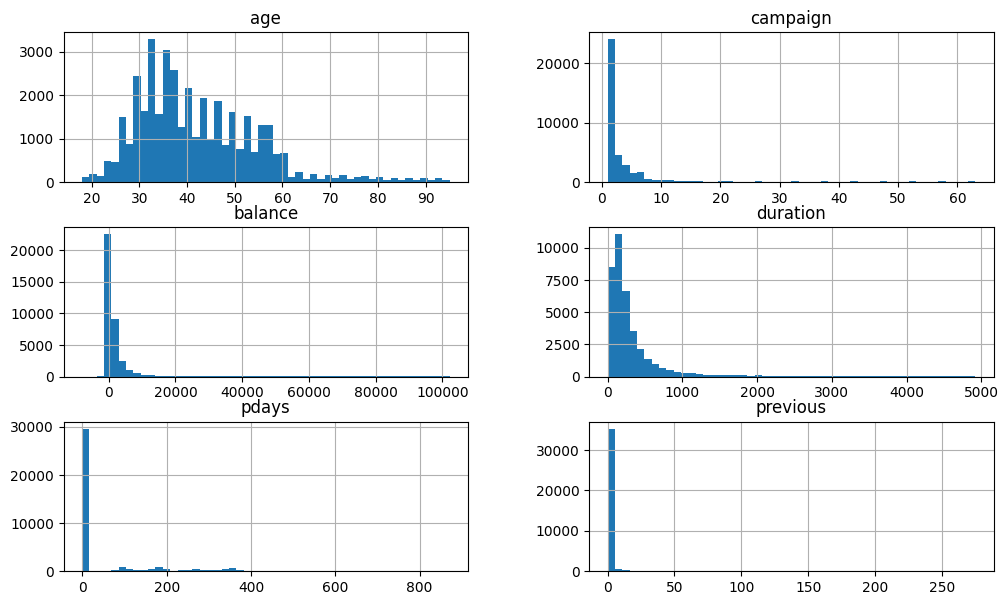

In [15]:

train_df[['age','campaign', 'balance', 'duration', 'pdays', 'previous']].hist(bins=50, figsize=(12,7))
plt.show()

### Call Duration Distribution
The `duration` feature is visualized separately due to its wide range and skewed distribution.

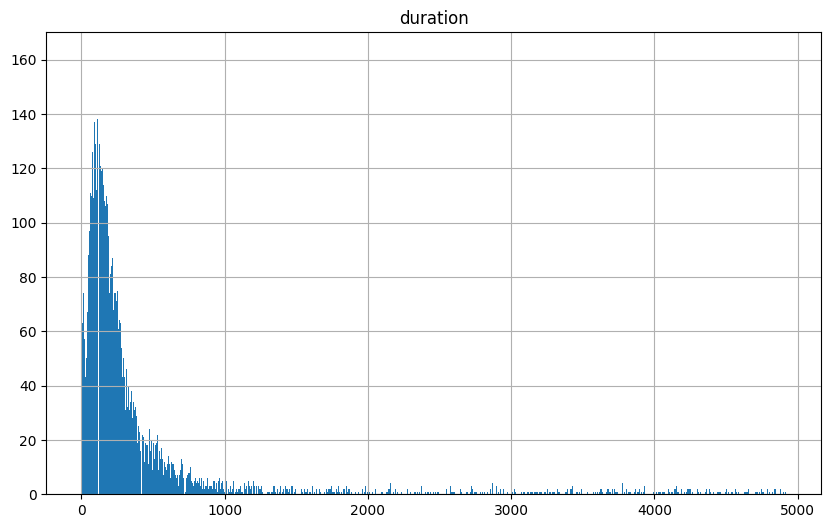

In [16]:
train_df[['duration']].hist(bins=5000, figsize=(10,6))
plt.show()

### Observations
- Missing values are present in categorical features such as `job`, `education`, `contact`, and `poutcome`.
- No missing values are observed in numerical features.

### Descriptive Statistics of Numerical Features
Summary statistics provide insight into central tendency, variability, and potential outliers.

In [17]:
train_df.describe()

,age,balance,duration,campaign,pdays,previous
count,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000,39211.000000
mean,42.120247,5441.781719,439.062789,5.108770,72.256051,11.826171
std,12.709352,16365.292065,769.096291,9.890153,160.942593,44.140259
min,18.000000,-8019.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,98.000000,109.000000,1.000000,-1.000000,0.000000
50%,40.000000,549.000000,197.000000,2.000000,-1.000000,0.000000
75%,50.000000,2030.000000,380.000000,4.000000,-1.000000,0.000000
max,95.000000,102127.000000,4918.000000,63.000000,871.000000,275.000000


### Key Insights from Numerical Features

- **Age:** The average customer age is approximately 42 years, indicating a predominantly middle-aged population.
- **Balance:** The mean balance is 5,441, with a very high standard deviation(16365.3), suggesting significant variation and the presence of large outliers.
- **Duration:** The average call duration is around 439 seconds(7.3 minutes); however, the high standard deviation (769) indicates some unusually long calls.
- **Campaign:** The number of contacts per campaign ranges from 1 to 63, with a median of 2. This indicates that **most clients are contacted a few times**. Mean is 5.1, but the high standard deviation (9.9) indicates there are cases with many more contacts, suggesting possible** outliers** in the number of campaign contacts.
- **Pdays:** (Days Since Last Contact) The 25th, 50th, and 75th percentiles are all -1, implying that most clients were not contacted in previous campaigns.
- **Previous:** Most clients had no prior contacts(median = 0), while a small number were contacted many times( mean = 11.8 and high standard deviation = (44.1)), again indicating outliers.



### Summary of Categorical Features
Reviewing frequency and distribution of categorical variables.

In [18]:
train_df.describe(include='object')

,last contact date,job,marital,education,default,housing,loan,contact,poutcome,target
count,39211,38982,39211,37744,39211,39211,39211,28875,9760,39211
unique,1013,11,3,3,2,2,2,2,3,2
top,2009-05-15,blue-collar,married,secondary,no,yes,no,cellular,failure,no
freq,313,7776,22691,19584,36954,21657,31820,25030,4949,33384


### Duplicate Record Check
No duplicate records were found in the training dataset.

In [19]:
train_df.duplicated().value_counts()

False    39211
Name: count, dtype: int64

## 6. Outlier Analysis (Numerical Features)

In [20]:
# Summary statistics for selected numerical columns

train_df[['campaign', 'balance', 'duration']].describe()

,campaign,balance,duration
count,39211.000000,39211.000000,39211.000000
mean,5.108770,5441.781719,439.062789
std,9.890153,16365.292065,769.096291
min,1.000000,-8019.000000,0.000000
25%,1.000000,98.000000,109.000000
50%,2.000000,549.000000,197.000000
75%,4.000000,2030.000000,380.000000
max,63.000000,102127.000000,4918.000000


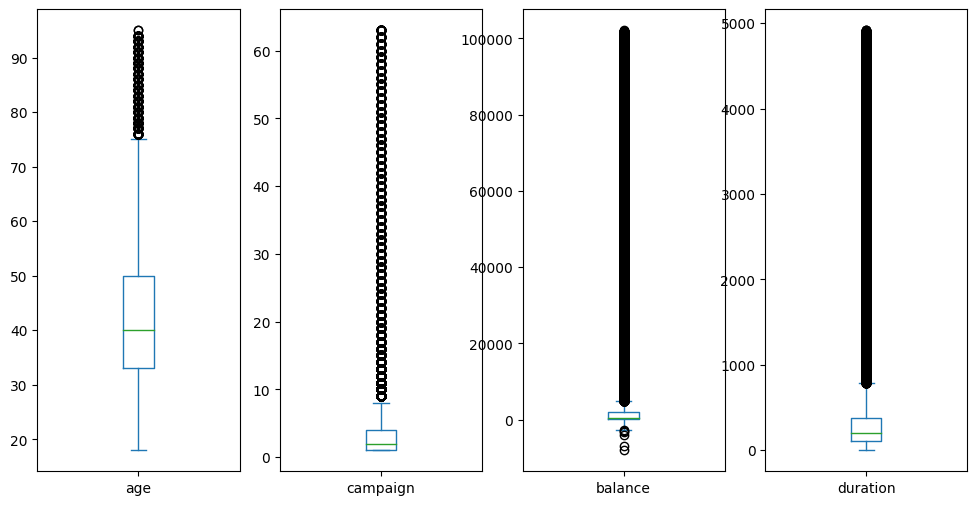

In [21]:
# Box plots

train_df[['age', 'campaign', 'balance', 'duration']].plot(kind='box', subplots=True, figsize=(12,6))
plt.show()

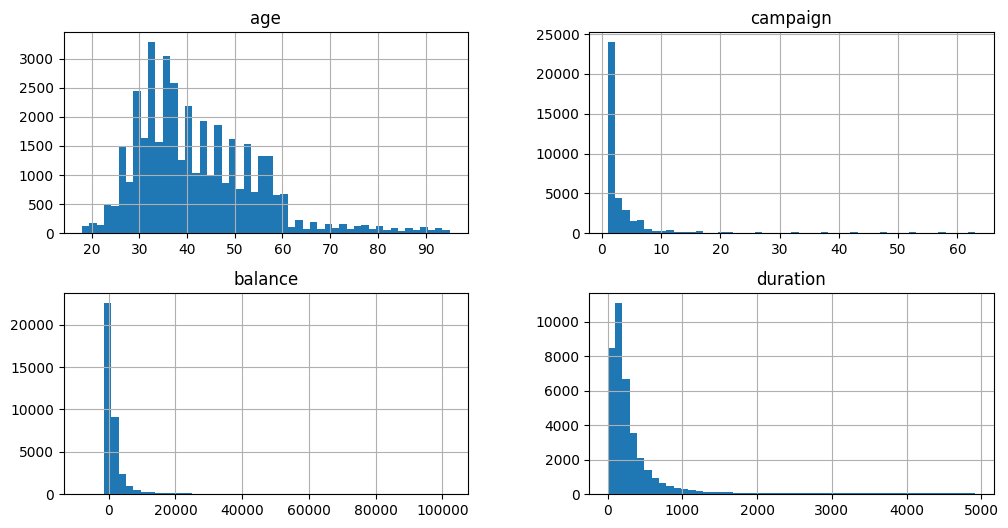

In [22]:
# histogram for age, campaign, balance, duration

train_df[['age','campaign', 'balance', 'duration']].hist(bins=50, figsize=(12,6))
plt.show()

In [23]:
# Skewness & Kurtosis

skewness = train_df[['campaign', 'balance', 'duration']].skew()
kurtosis = train_df[['campaign', 'balance', 'duration']].kurtosis()

print(f"Skewness:\n{skewness}")
print(f"Kurtosis:\n{kurtosis}")

Skewness:
campaign    3.839593
balance     4.063587
duration    3.700585
dtype: float64
Kurtosis:
campaign    15.027613
balance     16.309795
duration    14.234990
dtype: float64


In [24]:
# Outlier percentage using IQR

def outlier_percentage_iqr(df, column):
    Q1 = df[column].quantile(0.25)  
    Q3 = df[column].quantile(0.75)  
    IQR = Q3 - Q1  

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    num_outliers = len(outliers)

    percentage = (num_outliers / len(df)) * 100
    return num_outliers, percentage

for col in ['campaign', 'balance', 'duration', 'age']:
    num_outliers, percent = outlier_percentage_iqr(train_df, col)
    print(f"{col}: {num_outliers} outliers ({percent:.2f}%)")

campaign: 4170 outliers (10.63%)
balance: 5374 outliers (13.71%)
duration: 4306 outliers (10.98%)
age: 1002 outliers (2.56%)


**Findings:**
- Skewness > 3 → heavily right‑skewed.
- Kurtosis > 3 → extreme outliers.
- `campaign`, `balance`, `duration` are highly right skewed with extreme outliers.

## 7. Exploring Categorical Features

In [25]:
# List categorical columns

cat_cols = train_df.select_dtypes(include = 'object').columns
cat_cols

Index(['last contact date', 'job', 'marital', 'education', 'default',
       'housing', 'loan', 'contact', 'poutcome', 'target'],
      dtype='object')

In [26]:
# Show unique values count

for col in cat_cols:
    print(col,':', train_df[col].unique())

last contact date : ['2009-04-17' '2009-10-11' '2010-11-20' ... '2009-07-05' '2008-02-25'
 '2010-04-12']
job : ['blue-collar' 'technician' 'admin.' 'entrepreneur' 'unemployed'
 'management' 'services' 'student' 'self-employed' 'retired' 'housemaid'
 nan]
marital : ['married' 'single' 'divorced']
education : ['secondary' 'tertiary' 'primary' nan]
default : ['no' 'yes']
housing : ['yes' 'no']
loan : ['no' 'yes']
contact : ['cellular' 'telephone' nan]
poutcome : ['other' nan 'failure' 'success']
target : ['no' 'yes']


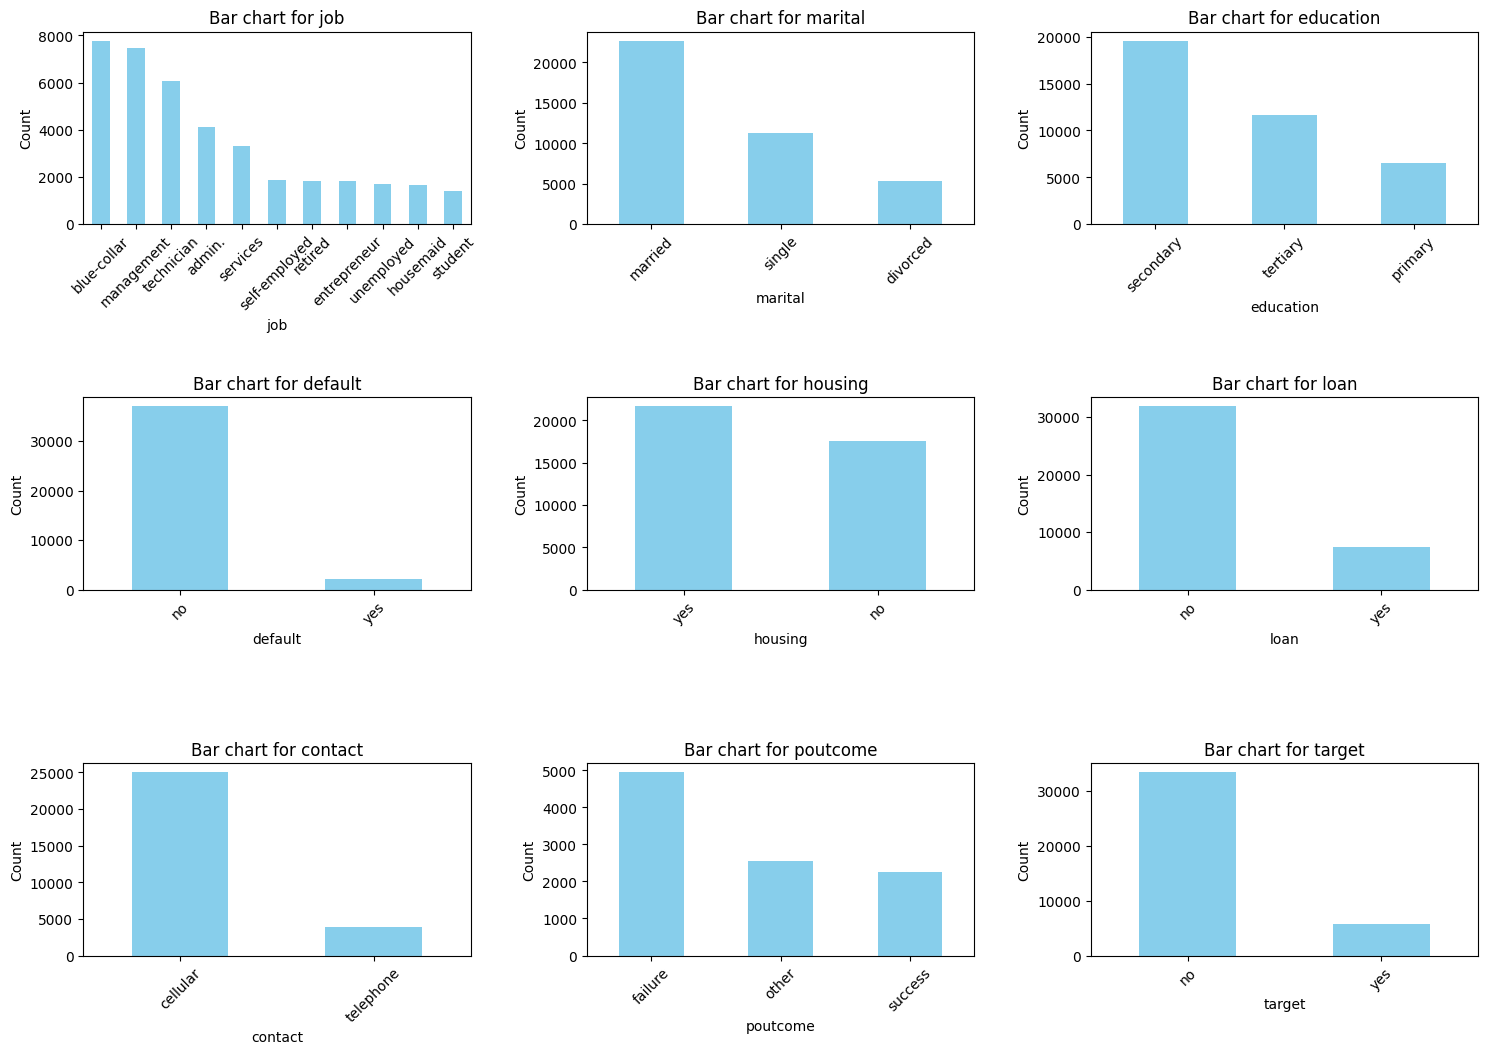

In [27]:
# Bar charts for categorical columns

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'target']

fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(18, 12))

axes = axes.flatten()

# Plot each categorical column
for i, col in enumerate(categorical_cols):
    train_df[col].value_counts().plot(kind='bar', ax=axes[i], color="skyblue")
    axes[i].set_title(f"Bar chart for {col}")
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis='x', rotation=45)


plt.subplots_adjust(hspace=0.9, wspace=0.3) 

plt.show()

**Interpretation:**
- Most customers are married and have secondary education.
- Housing loans are common, while personal loans are less frequent.
- Target variable is imbalanced (majority 'no').

## 8. Preprocessing & Feature Engineering

In [1]:
# Define column groups

numerical_cols = ['age', 'pdays', 'previous']

label_encoded_cols = ['default', 'housing', 'loan']   # binary yes/no

onehot_encoded_cols = ['marital', 'job', 'education', 'contact', 'poutcome']

### Feature Engineering (Date Features)
#### Converted 'last contact date' into year, month, weekday, and weekend indicator.

In [29]:
def extract_date_features(df):
    df['last_contact_year'] = df['last contact date'].dt.year
    df['last_contact_month'] = df['last contact date'].dt.month
    df['last_contact_weekday'] = df['last contact date'].dt.weekday # mon=0, tues=1 .... sun=6
    df['is_weekend'] = df['last_contact_weekday'].apply(lambda x: 1 if x >= 5 else 0)  # 1 for weekend (Sat/Sun), 0 for weekday
    return df.drop(columns=['last contact date']) 

In [30]:
date_transformer = FunctionTransformer(extract_date_features, validate=False)

In [31]:
# Convert date column to datetime

train_df['last contact date'] = pd.to_datetime(train_df['last contact date'], format='%Y-%m-%d', errors='coerce') # 'coerce': Ensures that any non-parsable dates are converted to NaT (Not a Time) instead of throwing an error.
test_df['last contact date'] = pd.to_datetime(test_df['last contact date'], format='%Y-%m-%d', errors='coerce')

### Data Cleaning & Log Transformations
#### - Balance column shifted to remove negatives.
#### - Duration column shifted to remove zeros.

In [32]:
# Balance adjustment
train_df['balance'] += (-train_df['balance'].min() + 1)
test_df['balance'] += (-test_df['balance'].min() + 1)

# Duration adjustment
train_df['duration'] += 1
test_df['duration'] += 1

In [33]:
numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)), # Fill missing values with the most frequent value
    ('scaler', MinMaxScaler())  # range [0, 1]
])

label_encoded_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent', missing_values=np.nan)), 
    ('label_encoder', OrdinalEncoder())  
])

onehot_encoded_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='unknown')),  # Fill missing values with the most frequent value
    ('onehot', OneHotEncoder(handle_unknown='ignore',sparse_output=False)) 
])

log_transformer = FunctionTransformer(lambda X: np.log1p(X), validate=False) # validate=False: to allow input as more than 2D array

In [35]:
preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_cols), 
    ('label_enc', label_encoded_transformer, label_encoded_cols),
    ('onehot_enc', onehot_encoded_transformer, onehot_encoded_cols),
    ('date', date_transformer, ['last contact date']), 
    ('log_transform', log_transformer, ['campaign', 'balance', 'duration']),
], remainder='passthrough', verbose_feature_names_out=False).set_output(transform="pandas")

/opt/conda/lib/python3.10/site-packages/sklearn/preprocessing/_function_transformer.py:343: UserWarning: With transform="pandas", `func` should return a DataFrame to follow the set_output API.
  warnings.warn(


In [38]:
X = train_df.drop('target', axis=1)
y = train_df['target']
X_train, X_valid, y_train, y_valid = train_test_split(X, y, 
                                                      test_size=0.30, 
                                                      random_state=42, 
                                                      stratify=y) # stratify ensures train and valid set has same proportion of classes as target

In [39]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_valid_transformed = preprocessor.transform(X_valid)
test_df_transformed = preprocessor.transform(test_df)

### Correlation Analysis
#### Checked for highly correlated features (threshold = 0.8).

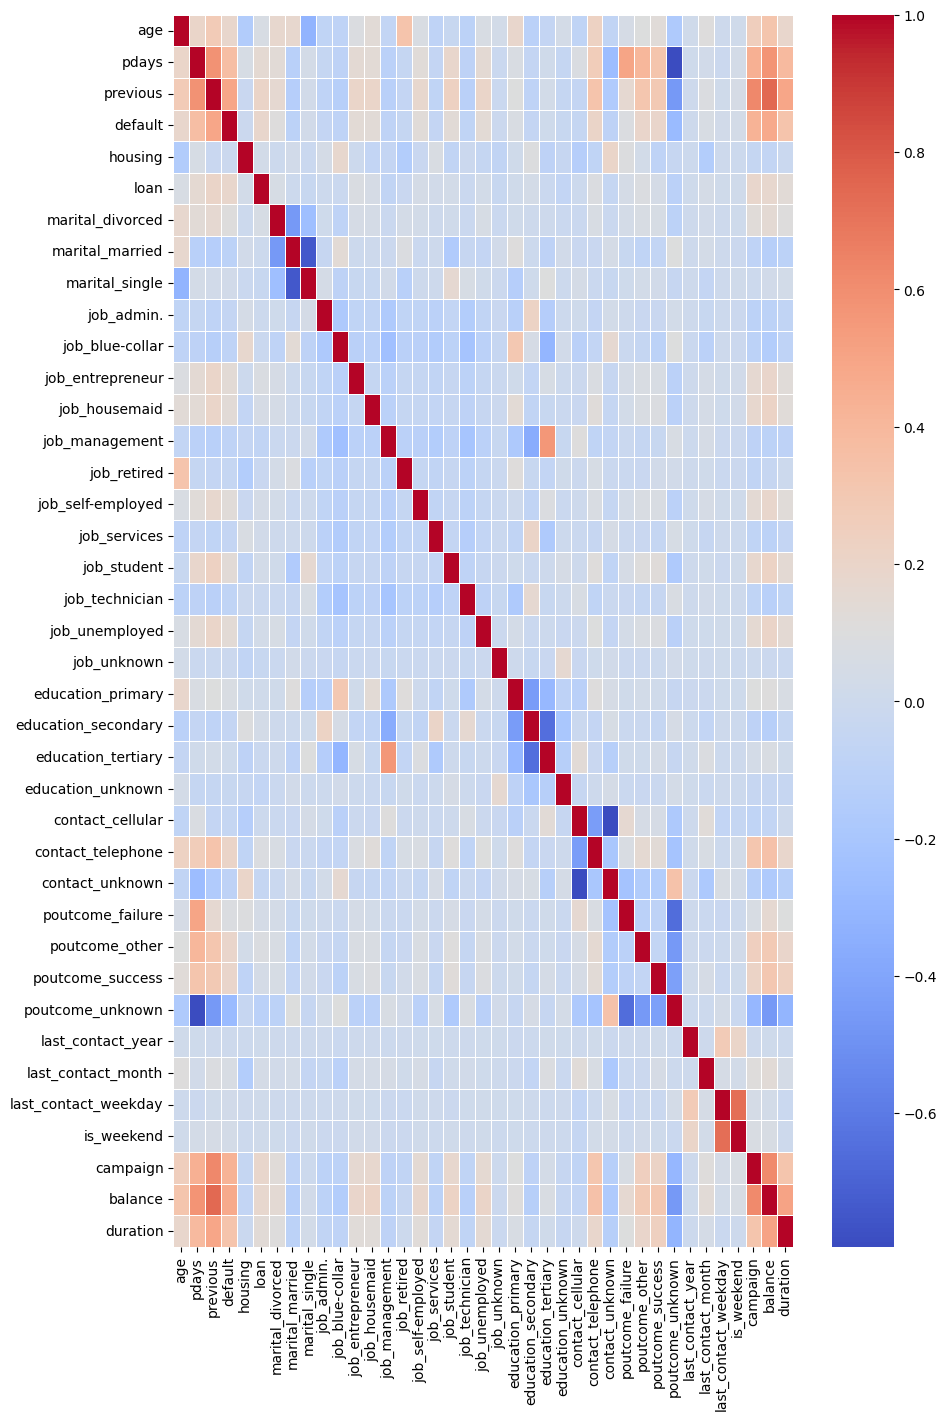

[]

In [43]:
# Set a correlation threshold for feature selection
threshold = 0.8

# Get pairs of features that are highly correlated
corr_matrix = X_train_transformed.corr()
plt.figure(figsize=(10,16))
sns.heatmap(corr_matrix, cmap='coolwarm', linewidth=0.4)
plt.show()

upper_triangle = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Identify columns with correlation greater than the threshold
to_drop = [column for column in upper_triangle.columns if any(upper_triangle[column].abs() > threshold)]

to_drop

## 9. Modeling


## 9.1 Logistic Regression

Logistic Regression was used as a baseline linear model for binary classification.  

In [ ]:
clf_lr = LogisticRegression(class_weight='balanced', 
                            max_iter=500, # algo can take up to 500 iterations to find the best-fitting parameters
                            random_state=42)

clf_lr.fit(X_train_transformed, y_train)
y_valid_pred_lr = clf_lr.predict(X_valid_transformed)

### Evaluation:

In [ ]:
f1_valid_LogReg = f1_score(y_valid, y_valid_pred_lr, average='macro')
f1_valid_LogReg

**Observation:** 

This model provided a good baseline for the project.  
However, its performance was relatively lower compared to other models, indicating that simple linear methods might not capture all relationships within the data.

## 9.2 Random Forest
Random Forest was used to capture non-linear relationships by combining multiple
decision trees and reducing overfitting through ensemble learning.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300], # num of trees in Random Forest
    'max_depth': [20, 30, 40], # max depth of each tree
    'min_samples_split': [2, 5, 10], # minimum number of samples required to split a node
    'min_samples_leaf': [5, 6, 7]
}

f1_scorer = make_scorer(f1_score, average='macro')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search_rf = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42),
    param_grid,
    scoring=f1_scorer,
    cv=skf,
    n_jobs=-1,
    verbose=3
)

grid_search_rf.fit(X_train_transformed, y_train)
best_rf_model = grid_search_rf.best_estimator_


### Validation

In [ ]:
y_valid_pred_rf = best_rf_model.predict(X_valid_transformed)
f1_rf = f1_score(y_valid, y_valid_pred_rf, average='macro')
f1_rf

**Observation:**

The Random Forest model showed a significant improvement over Logistic Regression.  
By leveraging multiple decision trees, it captured complex feature interactions and reduced overfitting, making it one of the strongest models in this study.

## 9.3 Feature Importance & Selection 

### Feature Importance Analysis

Feature importance was extracted from the trained Random Forest model
to identify the most influential predictors.

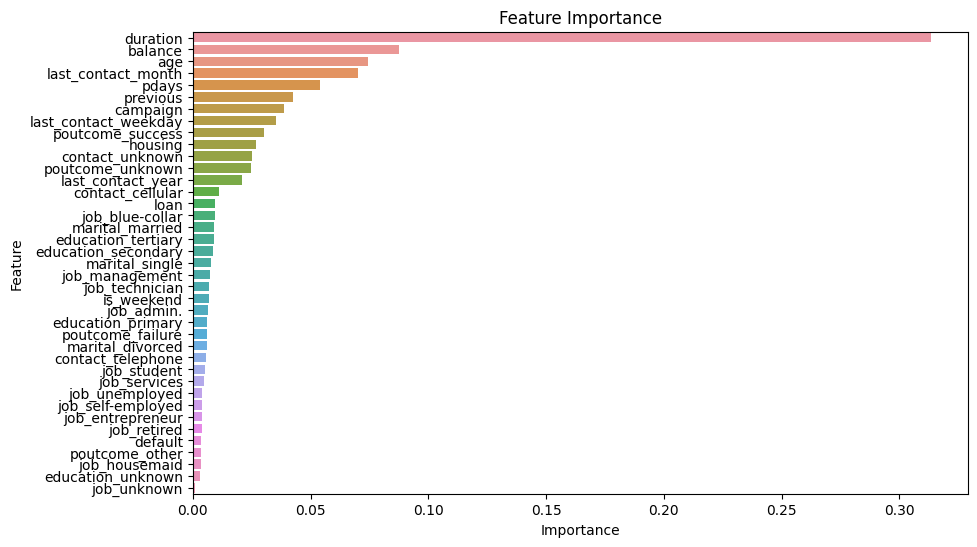

In [60]:
feature_importances = rf_model.feature_importances_

feature_importance_df_rf = pd.DataFrame({
    'Feature': X_train_transformed.columns,
    'Importance': feature_importances
}).sort_values(by='Importance', ascending=False)

# Plot feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df_rf)
plt.title("Feature Importance")
plt.show()

In [ ]:
# Top Features
top_n = 25
top_features = feature_importance_df.head(top_n)['Feature']

X_train_reduced = X_train_transformed[top_features]
X_valid_reduced = X_valid_transformed[top_features]

In [ ]:
# Retrain on Reduced Features
best_rf_model.fit(X_train_reduced, y_train)
y_valid_pred_rf_reduced = best_rf_model.predict(X_valid_reduced)

f1_rf_reduced = f1_score(y_valid, y_valid_pred_rf_reduced, average='macro')
f1_rf_reduced

**Observation:**

Using the most important features maintained similar performance

## 9.4 Decision Tree

A model that splits the data into branches based on feature values to make decisions, creating a tree-like structure.

In [ ]:
dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='entropy',
    max_depth=8,
    min_samples_leaf=7,
    min_samples_split=10,
    random_state=42
)

dt_model.fit(X_train_transformed, y_train)
y_valid_pred_dt = dt_model.predict(X_valid_transformed)

f1_dt = f1_score(y_valid, y_valid_pred_dt, average='macro')
f1_dt

**Observation:**

The Decision Tree model performed only slightly better than Logistic Regression.  
Its simplicity and limited depth restricted its ability to capture complex patterns.  
This highlights the limitations of single‑tree models compared to ensemble methods like Random Forest.

## 9.5 Naive Bayes

A probabilistic classifier that applies Bayes' theorem, assuming feature independence.
The probability of an event based on prior knowledge of conditions that might be related to the event.

In [ ]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_valid_encoded = label_encoder.transform(y_valid)

In [ ]:
best_nb_model = GaussianNB(priors=[0.8, 0.2], var_smoothing=1e-6)
best_nb_model.fit(X_train_poly, y_train_encoded)

y_valid_pred_nb = best_nb_model.predict(X_valid_poly)
f1_nb = f1_score(y_valid_encoded, y_valid_pred_nb, average='macro')
f1_nb

**Observation:**

Naive Bayes had the lowest performance among all models.  
This is likely due to its assumption of feature independence, which does not hold well for this dataset where variables are correlated.

## 9.6 Bagging with Random Forest

An ensemble technique that builds multiple models on random subsets of data (bagging) to reduce variance
Bagging reduces overfitting and reduces variance by training multiple instances in parallel

Since Random Forest already performs internal bagging, only marginal improvement was observed.

In [ ]:
bagging_model = BaggingClassifier(
    estimator=best_rf_model,
    n_estimators=10,
    random_state=42,
    n_jobs=-1
)

bagging_model.fit(X_train_transformed, y_train_encoded)
y_pred_bagging = bagging_model.predict(X_valid_transformed)

f1_bagging = f1_score(y_valid_encoded, y_pred_bagging, average='macro')
f1_bagging


**Observation:**

Bagging slightly improved over the base Random Forest.  
While it reduced variance and added robustness, the gain was marginal, suggesting that Random Forest was already strong enough without additional bagging.

## 9.7 XGBoost

An advanced gradient boosting technique that builds trees sequentially, optimizing for errors from previous trees.

In [99]:
f1_xgb = f1_score(y_valid_encoded, y_valid_pred_xgb, average='macro')
f1_xgb

0.769365849606517

**Observation:**

XGBoost provided the best score among all models tested.  
Its strong performance is attributed to iterative boosting of weak learners, which effectively reduces both bias and variance.  
This model demonstrated the highest predictive power and generalization ability.

## 10. Model Comparison

In [ ]:
model_scores = {
    "Logistic Regression": f1_valid_LogReg,
    "Decision Tree": f1_dt,
    "Naive Bayes": f1_nb,
    "Random Forest": f1_rf,
    "Bagging with RF": f1_bagging,
    "XGBoost": f1_xgb
}

The comparison shows that ensemble-based models significantly outperform
single estimators, with XGBoost achieving the best results.

## 11. Final Model and Submission

Based on validation performance, XGBoost was selected as the final model.

In [ ]:
y_test_pred_xgb = best_xgb_model.predict(test_df_transformed)
y_test_pred = np.where(y_test_pred_xgb == 1, 'yes', 'no')

## 12. Submission

In [ ]:
submission = pd.DataFrame({
    'id': test_df.index,
    'target': y_test_pred
})

submission.to_csv('submission.csv', index=False)
submission.head()
